# Expected SARSA and $n$-step bootstrapping 

In this notebook, you will implement expected SARSA and $n$-step bookstrapping described in Chapters 6 and 7 of [Sutton and Barto's book, Introduction to Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html).  

### Install dependencies

In [1]:
! pip install numpy pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\chris\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Imports

In [2]:
import numpy as np
import random
import sys          # We use sys to get the max value of a float
import pandas as pd # We only use pandas for displaying tables nicely
pd.options.display.float_format = '{:,.3f}'.format

### ```World``` class and globals

The ```World``` is a grid represented as a two-dimensional array of characters where each character can represent free space, an obstacle, or a terminal. Each non-obstacle cell is associated with a reward that an agent gets for moving to that cell (can be 0). The size of the world is _width_ $\times$ _height_ characters.

A _state_ is a tuple $(x,y)$.

An empty world is created in the ```__init__``` method. Obstacles, rewards and terminals can then be added with ```add_obstacle``` and ```add_reward```.

To calculate the next state of an agent (that is, an agent is in some state $s = (x,y)$ and performs and action, $a$), ```get_next_state()```should be called.

In [3]:
# Globals:
ACTIONS = ("up", "down", "left", "right") 

# Rewards, terminals and obstacles are characters:
REWARDS = {" ": 0, ".": 0.1, "+": 10, "-": -10}
TERMINALS = ("+", "-") # Note a terminal should also have a reward assigned
OBSTACLES = ("#")

# Discount factor
gamma = 1

# The probability of a random move:
rand_move_probability = 0

class World:  
  def __init__(self, width, height):
    self.width = width
    self.height = height
    # Create an empty world where the agent can move to all cells
    self.grid = np.full((width, height), ' ', dtype='U1')
  
  def add_obstacle(self, start_x, start_y, end_x=None, end_y=None):
    """
    Create an obstacle in either a single cell or rectangle.
    """
    if end_x == None: end_x = start_x
    if end_y == None: end_y = start_y
    
    self.grid[start_x:end_x + 1, start_y:end_y + 1] = OBSTACLES[0]

  def add_reward(self, x, y, reward):
    assert reward in REWARDS, f"{reward} not in {REWARDS}"
    self.grid[x, y] = reward

  def add_terminal(self, x, y, terminal):
    assert terminal in TERMINALS, f"{terminal} not in {TERMINALS}"
    self.grid[x, y] = terminal

  def is_obstacle(self, x, y):
    if x < 0 or x >= self.width or y < 0 or y >= self.height:
      return True
    else:
      return self.grid[x ,y] in OBSTACLES 

  def is_terminal(self, x, y):
    return self.grid[x ,y] in TERMINALS

  def get_reward(self, x, y):
    """ 
    Return the reward associated with a given location
    """ 
    return REWARDS[self.grid[x, y]]

  def get_next_state(self, current_state, action):
    """
    Get the next state given a current state and an action. The outcome can be
    stochastic  where rand_move_probability determines the probability of 
    ignoring the action and performing a random move.
    """    
    assert action in ACTIONS, f"Unknown acion {action} must be one of {ACTIONS}"
    
    x, y = current_state 
    
    # If our current state is a terminal, there is no next state
    if self.grid[x, y] in TERMINALS:
      return None

    # Check of a random action should be performed:
    if np.random.rand() < rand_move_probability:
      action = np.random.choice(ACTIONS)

    if action == "up":      y -= 1
    elif action == "down":  y += 1
    elif action == "left":  x -= 1
    elif action == "right": x += 1

    # If the next state is an obstacle, stay in the current state
    return (x, y) if not self.is_obstacle(x, y) else current_state


## A simple world

We will create a simple $8\times8$ world, where the agent should start in the top-left corner at $(0,0)$ and find its way to the bottom-right corner at $(7,7)$.

In [4]:
world = World(8, 8)
world.add_terminal(7, 7, "+")

print(world.grid.T)

[[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' '+']]


In [5]:
def q_visualizer(world : World, q : np.ndarray) -> None:
    new_q = np.full((world.width, world.height), "", dtype=object)
    action_symbols = {
        'up': '↑',
        'down': '↓', 
        'left': '←',
        'right': '→'
    }
    for x in range(world.width):
        for y in range(world.height):
            if world.is_terminal(x, y):
                if world.get_reward(x, y) > 0:
                    new_q[x, y] = '+'
                elif world.get_reward(x, y) < 0:
                    new_q[x, y] = '-'
            elif world.is_obstacle(x, y):
                new_q[x, y] = '#'
            elif q[x, y, :].all() == 0.0:
                new_q[x, y] = ' '
            else:
                new_q[x, y] = action_symbols[ACTIONS[np.argmax(q[x, y, :])]]

    print("Best action at each state (arrows show direction):")
    display(pd.DataFrame(new_q.T))

## Exercise: Expected SARSA

Implement and test expected SARSA, see page 133 of [Introduction to Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html). The implementation of expected SARSA is very similar to regular SARSA, so you can use your SARSA implementation as a starting point for your expected SARSA implementation.

In [6]:
def initialize_q_table(world, q_table):
    for x in range(world.height):
        for y in range(world.width):
            for a in range(len(ACTIONS)):
                if not world.is_terminal(x, y):
                    q_table[x, y, a] = random.random()

In [7]:
# TODO: Implement your code here -- you need a Q-table to keep track of action 
#       value estimates and a policy-function that returns an epsilon greedy 
#       policy based on your estimates. 

def expected_sarsa(world, start_state, alpha=0.5, gamma=0.9, epsilon=0.1, episodes=1000, max_steps=1000):
    Q_table = np.full((world.width, world.height, len(ACTIONS)), 0.0) # Q_table[x, y, a_idx]
    # initialize_q_table(world, Q_table)
    all_steps = []
    policy = lambda state, q_func=Q_table : {k : 1-epsilon+epsilon/len(ACTIONS) 
                                             if k == ACTIONS[np.argmax(q_func[*state, :])] 
                                             else epsilon/len(ACTIONS) for k in ACTIONS}
    for _ in range(episodes):
        current_state = start_state
        next_state = None
        steps = 0
        # print(f"Episode no: {_}")
        
        while not world.is_terminal(*current_state) and steps < max_steps:
            action_prob = policy(current_state)
            action = random.choices(population=list(action_prob.keys()),
                                    weights=action_prob.values(), k=1)[0]
            action_idx = ACTIONS.index(action)
            next_state = world.get_next_state(current_state, action)
            reward = world.get_reward(*next_state)
            next_action_prob = policy(next_state) 

            if world.is_terminal(*next_state): # if next state is terminal then break
                Q_table[*current_state, action_idx] += alpha * (reward - Q_table[*current_state, action_idx])
                break
            
            action_sum = 0
            for a in ACTIONS:
                action_sum += next_action_prob[a] * Q_table[*next_state, ACTIONS.index(a)] # sum(a_prob * Q(S', a'))

            Q_current = Q_table[*current_state, action_idx] # Q(S, A)
            Q_table[*current_state, action_idx] += alpha * (reward + gamma * action_sum - Q_current)

            current_state = next_state
            steps += 1
        all_steps.append(steps)
    return Q_table, all_steps

Try your expected SARSA implementation on the $8\times8$ world defined above.

In [8]:
REWARDS = {" ": 0, "#": -1, "+": 10, "-": -10}

big_map = World(10, 10)
big_map.add_terminal(9, 0, "+")
big_map.add_terminal(9, 9, "+")
big_map.add_terminal(0, 9, "+")
big_map.add_terminal(0, 0, "+")
obstacles = [(1, 1), (2, 1), (3, 1), (7, 0), (2, 2), (2, 3), (7, 2), (7, 3), (2, 8), (2, 9), (7, 7), (7, 8)]
for x, y in obstacles:
    big_map.add_obstacle(x, y)

display(pd.DataFrame(big_map.grid.T))
q_q_sarsa = expected_sarsa(big_map, (5,5))
q_visualizer(big_map, q_q_sarsa)

,0,1,2,3,4,5,6,7,8,9
0,+,,,,,,,#,,+
1,,#,#,#,,,,,,
2,,,#,,,,,#,,
3,,,#,,,,,#,,
4,,,,,,,,,,
5,,,,,,,,,,
6,,,,,,,,,,
7,,,,,,,,#,,
8,,,#,,,,,#,,
9,+,,#,,,,,,,+


TypeError: tuple indices must be integers or slices, not tuple

### Test and compare your expected SARSA implementation

Test your implementation on the simple $8 \times 8$ world defined above with, ```rand_move_probability = 0.0```, $\epsilon = 0.1$, and $\gamma = 0.9$. Compare the performance of expected SARSA with normal SARSA. How long does it take for the respective methods to solve the tasks optimally (that is, number of steps that an agent takes from start to finish = _width_ + _height_ $-2 = 14$). 

Remember that for expected SARSA, you can use a learning rate of 1 ($\alpha = 1)$, whereas for SARSA, you should try different learning rates.


In [9]:
def sarsa(world, start_state, alpha=0.5, gamma=0.9, epsilon=0.1, episodes=1000, max_steps=1000):
    Q_table = np.full((world.width, world.height, len(ACTIONS)), 0.0) # Q_table[x, y, a_idx]
    # initialize_q_table(world, Q_table)
    all_steps = []
    policy = lambda state, q_func=Q_table : {k : 1-epsilon+epsilon/len(ACTIONS) 
                                             if k == ACTIONS[np.argmax(q_func[*state, :])] 
                                             else epsilon/len(ACTIONS) for k in ACTIONS}
    for _ in range(episodes):
        current_state = start_state
        next_state = None
        action_prob = policy(current_state)
        action = random.choices(population=list(action_prob.keys()),
                                    weights=action_prob.values(), k=1)[0]
        steps = 0

        while not world.is_terminal(*current_state) and steps < max_steps:
            next_state = world.get_next_state(current_state, action)
            reward = world.get_reward(*next_state)
            next_action_prob = policy(next_state)
            next_action = random.choices(population=list(next_action_prob.keys()),
                                    weights=next_action_prob.values(), k=1)[0]
            next_action_idx = ACTIONS.index(next_action)
            action_idx = ACTIONS.index(action)
            if world.is_terminal(*next_state): # if next state is None (terminal) then break
                Q_table[*current_state, action_idx] += alpha * (reward - Q_table[*current_state, action_idx])
                break
            
            Q_current = Q_table[*current_state, action_idx] # Q(S, A)
            Q_next = Q_table[*next_state, next_action_idx]  # Q(S', A')
            Q_table[*current_state, action_idx] += alpha * (reward + gamma * Q_next - Q_current)

            current_state = next_state
            action = next_action
            steps += 1
        all_steps.append(steps)
    return Q_table, all_steps

In [10]:
REWARDS = {" ": 0, "#": -1, "+": 10, "-": -10}

big_map = World(10, 10)
big_map.add_terminal(9, 0, "+")
big_map.add_terminal(9, 9, "+")
big_map.add_terminal(0, 9, "+")
big_map.add_terminal(0, 0, "+")
obstacles = [(1, 1), (2, 1), (3, 1), (7, 0), (2, 2), (2, 3), (7, 2), (7, 3), (2, 8), (2, 9), (7, 7), (7, 8)]
for x, y in obstacles:
    big_map.add_obstacle(x, y)

display(pd.DataFrame(big_map.grid.T))
q_q_sarsa = sarsa(world=big_map, start_state=(5,5), alpha=0.5, gamma=0.9, epsilon=0.1, episodes=10000)
q_visualizer(big_map, q_q_sarsa)

,0,1,2,3,4,5,6,7,8,9
0,+,,,,,,,#,,+
1,,#,#,#,,,,,,
2,,,#,,,,,#,,
3,,,#,,,,,#,,
4,,,,,,,,,,
5,,,,,,,,,,
6,,,,,,,,,,
7,,,,,,,,#,,
8,,,#,,,,,#,,
9,+,,#,,,,,,,+


TypeError: tuple indices must be integers or slices, not tuple

In [11]:
rand_move_probability = 0.0
epsilon = 0.1
gamma = 0.9

### TODO: Compare the performance of SARSA (different alphas) and 
###       expected SARSA (alpha = 1). You need to run multiple 
###       experiments (e.g. 100 per setting) and then take the average 
###       to get a proper estimate of the general performance.
# ...existing code...
import matplotlib.pyplot as plt

def count_steps_to_goal(world, q_table, start_state, max_steps=1000):
    """
    Count steps needed to reach the goal using the learned Q-table.
    Returns the number of steps or max_steps if goal not reached.
    """
    current_state = start_state
    steps = 0
    
    while not world.is_terminal(*current_state) and steps < max_steps:
        # Follow greedy policy (no exploration)
        action_idx = np.argmax(q_table[*current_state, :])
        action = ACTIONS[action_idx]
        current_state = world.get_next_state(current_state, action)
        steps += 1
    
    return steps

def run_experiment(world, start_state, algorithm, alpha, gamma, epsilon, num_experiments=100, max_episodes=5000):
    """
    Run multiple experiments and track performance over episodes.
    Returns average steps to goal across experiments for each episode checkpoint.
    """
    checkpoints = list(range(100, max_episodes + 1, 100))  # Check every 100 episodes
    avg_steps_per_checkpoint = []
    
    for checkpoint in checkpoints:
        steps_across_experiments = []
        
        for exp in range(num_experiments):
            if algorithm == "sarsa":
                q_table = sarsa(world, start_state, alpha=alpha, gamma=gamma, 
                              epsilon=epsilon, episodes=checkpoint)
            else:  # expected_sarsa
                q_table = expected_sarsa(world, start_state, alpha=alpha, gamma=gamma,
                                       epsilon=epsilon, episodes=checkpoint, max_steps=1000)
            
            steps = count_steps_to_goal(world, q_table, start_state)
            steps_across_experiments.append(steps)
        
        avg_steps = np.mean(steps_across_experiments)
        avg_steps_per_checkpoint.append(avg_steps)
        print(f"{algorithm.upper()} (α={alpha}): Episode {checkpoint}, Avg steps: {avg_steps:.2f}")
    
    return checkpoints, avg_steps_per_checkpoint

# Run experiments
rand_move_probability = 0.0
epsilon = 0.1
gamma = 0.9

# Create the world
world = World(8, 8)
world.add_terminal(7, 7, "+")
start_state = (0, 0)

num_experiments = 100
max_episodes = 2000

# Test different alpha values for SARSA
sarsa_alphas = [0.1, 0.3, 0.5, 0.7, 1.0]
sarsa_results = {}

for alpha in sarsa_alphas:
    print(f"\nRunning SARSA with alpha={alpha}...")
    checkpoints, avg_steps = run_experiment(world, start_state, "sarsa", alpha, gamma, 
                                           epsilon, num_experiments, max_episodes)
    sarsa_results[alpha] = (checkpoints, avg_steps)

# Test Expected SARSA with alpha=1
print(f"\nRunning Expected SARSA with alpha=1...")
expected_checkpoints, expected_avg_steps = run_experiment(world, start_state, "expected_sarsa", 
                                                          1.0, gamma, epsilon, 
                                                          num_experiments, max_episodes)

# Plot results
plt.figure(figsize=(12, 7))

# Plot SARSA with different alphas
for alpha in sarsa_alphas:
    checkpoints, avg_steps = sarsa_results[alpha]
    plt.plot(checkpoints, avg_steps, marker='o', label=f'SARSA (α={alpha})', linewidth=2)

# Plot Expected SARSA
plt.plot(expected_checkpoints, expected_avg_steps, marker='s', label='Expected SARSA (α=1.0)', 
         linewidth=2, linestyle='--', color='red')

# Add optimal line
optimal_steps = world.width + world.height - 2  # 14 steps
plt.axhline(y=optimal_steps, color='green', linestyle=':', linewidth=2, label=f'Optimal ({optimal_steps} steps)')

plt.xlabel('Number of Episodes', fontsize=12)
plt.ylabel('Average Steps to Goal', fontsize=12)
plt.title(f'SARSA vs Expected SARSA Performance Comparison\n({num_experiments} experiments per setting, ε={epsilon}, γ={gamma})', 
          fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY: Episodes to reach optimal performance (14 steps)")
print("="*60)

for alpha in sarsa_alphas:
    checkpoints, avg_steps = sarsa_results[alpha]
    for i, (ep, steps) in enumerate(zip(checkpoints, avg_steps)):
        if steps <= optimal_steps + 0.5:  # Allow small tolerance
            print(f"SARSA (α={alpha}): ~{ep} episodes")
            break
    else:
        print(f"SARSA (α={alpha}): Did not reach optimal within {max_episodes} episodes")

for i, (ep, steps) in enumerate(zip(expected_checkpoints, expected_avg_steps)):
    if steps <= optimal_steps + 0.5:
        print(f"Expected SARSA (α=1.0): ~{ep} episodes")
        break
else:
    print(f"Expected SARSA (α=1.0): Did not reach optimal within {max_episodes} episodes")


Running SARSA with alpha=0.1...


TypeError: tuple indices must be integers or slices, not tuple

## Exercise: $n$-step on-policy SARSA or $n$-step on-policy expected SARSA

Here, you should implement on-policy $n$-step bootstrapping. You can either implement $n$-step SARSA or $n$-step expected SARSA. See Chapter 7 in [Introduction to Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html) and page 147 for $n$-step SARSA.

Test you implementation with different values of $n$ either on the $8\times8$ world above or on the ```WindyGridWorld``` from previous lectures. It is up to you to decide how to measure performance: it could, for instance, be the average episode length after a limited number of episodes (for instance $10$), how long it takes to solve the task optimally, like in the exercise on expected SARSA above, or something else.

For the world that you choose, you have to answer the question: "What is a good value for $n$?"

In [ ]:
### TODO: Implment and test n-step SARSA or n-step expected SARSA.
# alpha should be [0, 1]
# epsilon should be small but > 0
# def sarsa(world, start_state, n = 1, alpha=0.5, gamma=0.9, epsilon=0.1, episodes=1000, max_steps=1000):
#     Q_table = np.full((world.width, world.height, len(ACTIONS)), 0.0) # Q_table[x, y, a_idx] #
#     initialize_q_table(world, Q_table) #
    
#     policy = lambda state, q_func=Q_table : {k : 1-epsilon+epsilon/len(ACTIONS) #
#                                              if k == ACTIONS[np.argmax(q_func[*state, :])] 
#                                              else epsilon/len(ACTIONS) for k in ACTIONS}
#     for _ in range(episodes):
#         current_state = start_state
#         next_state = None
#         action_prob = policy(current_state)
#         action = random.choices(population=list(action_prob.keys()),
#                                     weights=action_prob.values(), k=1)[0]
#         steps = 0

#         while not world.is_terminal(*current_state) and steps < max_steps:
#             next_state = world.get_next_state(current_state, action)
#             reward = world.get_reward(*next_state)
#             next_action_prob = policy(next_state)
#             next_action = random.choices(population=list(next_action_prob.keys()),
#                                     weights=next_action_prob.values(), k=1)[0]
#             next_action_idx = ACTIONS.index(next_action)
#             action_idx = ACTIONS.index(action)
#             if world.is_terminal(*next_state): # if next state is None (terminal) then break
#                 Q_table[*current_state, action_idx] += alpha * (reward - Q_table[*current_state, action_idx])
#                 break
            
#             Q_current = Q_table[*current_state, action_idx] # Q(S, A)
#             Q_next = Q_table[*next_state, next_action_idx]  # Q(S', A')
#             Q_table[*current_state, action_idx] += alpha * (reward + gamma * Q_next - Q_current)

#             current_state = next_state
#             action = next_action
#             steps += 1

#     return Q_table

In [25]:
import numpy as np
import random

def n_step_sarsa(world, start_state, n, Q_table=None, alpha=0.5, gamma=1.0, epsilon=0.1, episodes=1000, max_steps=1000):
    if Q_table is None:
        Q_table = np.full((world.width, world.height, len(ACTIONS)), 0.0) # Q_table[x, y, a_idx] #
    # initialize_q_table(world, Q_table) #
    all_steps = []    
    policy = lambda state, q_func=Q_table : {k : 1-epsilon+epsilon/len(ACTIONS) #
                                             if k == ACTIONS[np.argmax(q_func[*state, :])] 
                                             else epsilon/len(ACTIONS) for k in ACTIONS}

    for episode in range(episodes):

        # Ring buffers (size n+1)
        S = [None] * (n + 1)
        A = [None] * (n + 1)
        R = [0.0] * (n + 1)

        S[0] = start_state
        action_prob = policy(start_state)
        action = random.choices(population=list(action_prob.keys()),
                                    weights=action_prob.values(), k=1)[0]
        A[0] = ACTIONS.index(action)

        T = float("inf")
        t = 0
        steps = 0

        while True:

            if t < T and steps < max_steps:
                action_idx = A[t % (n + 1)]
                action = ACTIONS[action_idx]

                next_state = world.get_next_state(S[t % (n + 1)], action)
                reward = world.get_reward(*next_state)
                R[(t + 1) % (n + 1)] = reward
                S[(t + 1) % (n + 1)] = next_state

                if world.is_terminal(*next_state):
                    T = t + 1
                else:
                    action_prob = policy(next_state)
                    action = random.choices(population=list(action_prob.keys()),
                                                weights=action_prob.values(), k=1)[0]
                    A[(t + 1) % (n + 1)] = ACTIONS.index(action)

            tau = t - n + 1 

            if tau >= 0: # enters at t = 3 if n = 4

                G = 0.0
                for i in range(tau + 1, min(tau + n, T) + 1): # +1 to include T
                    G += (gamma ** (i - tau - 1)) * R[i % (n + 1)] # roughly: sum for gamma^i * R_1

                if tau + n < T: # if not end reached
                    s = S[(tau + n) % (n + 1)]
                    a = A[(tau + n) % (n + 1)]
                    G += (gamma ** n) * Q_table[*s, a] # G + q-value for tau + n'th step

                s_tau = S[tau % (n + 1)] # s to est.
                a_tau = A[tau % (n + 1)] # a to est.

                Q_table[*s_tau, a_tau] += alpha * (G - Q_table[*s_tau, a_tau]) # est.

            if tau == T - 1:
                break

            t += 1
            steps += 1
        all_steps.append(steps)

    return Q_table, all_steps



In [ ]:
REWARDS = {" ": -1, "#": -1, "+": 10, "-": -10}

big_map = World(10, 10)
big_map.add_terminal(9, 0, "+")
big_map.add_terminal(9, 9, "+")
big_map.add_terminal(0, 9, "+")
big_map.add_terminal(0, 0, "+")
obstacles = [(1, 1), (2, 1), (3, 1), (7, 0), (2, 2), (2, 3), (7, 2), (7, 3), (2, 8), (2, 9), (7, 7), (7, 8)]
for x, y in obstacles:
    big_map.add_obstacle(x, y)

display(pd.DataFrame(big_map.grid.T))
q_q_sarsa, _ = n_step_sarsa(world=big_map, start_state=(5,5), n=2, alpha=0.5, gamma=0.9, epsilon=0.1, episodes=10000)
q_visualizer(big_map, q_q_sarsa)

,0,1,2,3,4,5,6,7,8,9
0,+,,,,,,,#,,+
1,,#,#,#,,,,,,
2,,,#,,,,,#,,
3,,,#,,,,,#,,
4,,,,,,,,,,
5,,,,,,,,,,
6,,,,,,,,,,
7,,,,,,,,#,,
8,,,#,,,,,#,,
9,+,,#,,,,,,,+


Best action at each state (arrows show direction):


,0,1,2,3,4,5,6,7,8,9
0,+,,←,←,↓,↓,→,#,,+
1,↑,#,#,#,→,←,→,→,→,↑
2,↑,←,#,→,↓,←,↑,#,→,↑
3,↑,↑,#,↑,↑,↓,↓,#,→,↑
4,↑,↑,←,←,→,↓,↓,↓,↑,↑
5,↑,↑,←,←,→,↓,↓,↓,↓,↑
6,↓,↑,↓,←,→,→,→,→,↓,↓
7,↓,↓,←,←,←,↓,↓,#,↓,↓
8,↓,←,#,→,↓,↓,↓,#,↓,↓
9,+,,#,←,→,→,→,→,→,+


In [ ]:
import matplotlib.pyplot as plt

# Setup world for testing
rand_move_probability = 0.0
epsilon = 0.1
gamma = 0.9
world_test = World(8, 8)
world_test.add_terminal(7, 7, "+")
start_state = (0, 0)
optimal_steps = 14  # 8 + 8 - 2
REWARDS = {" ": -1, "#": -1, "+": 10, "-": -10}


def measure_performance(q_table, world, start_state, max_steps=1000):
    """
    Measure how many steps it takes to reach goal using learned Q-table (greedy policy).
    """
    current_state = start_state
    steps = 0
    
    while not world.is_terminal(*current_state) and steps < max_steps:
        action_idx = np.argmax(q_table[*current_state, :])
        action = ACTIONS[action_idx]
        current_state = world.get_next_state(current_state, action)
        steps += 1
    
    return steps

def run_comparison_test(world, start_state, n_values=[2, 4, 8], num_experiments=10, max_episodes=10000):
    """
    Compare SARSA, Expected SARSA, and n-step SARSA across different episode counts.
    """
    episode_counts = list(range(1000, max_episodes + 1, 1000))
    results = {
        'SARSA': [],
        'Expected SARSA': [],
    }
    
    # Add n-step SARSA results for each n
    for n in n_values:
        results[f'n-step SARSA (n={n})'] = []
    
    print("Running comparison test...")
    print(f"Experiments per setting: {num_experiments}")
    print(f"Episode counts: {episode_counts}\n")
    
    for episodes in episode_counts:
        print(f"Testing with {episodes} episodes...")
        
        # Test SARSA
        steps_sarsa = []
        for exp in range(num_experiments):
            q_table, _ = sarsa(world, start_state, alpha=0.5, gamma=gamma, 
                             epsilon=epsilon, episodes=episodes)
            steps = measure_performance(q_table, world, start_state)
            steps_sarsa.append(steps)
        avg_steps_sarsa = np.mean(steps_sarsa)
        results['SARSA'].append(avg_steps_sarsa)
        print(f"  SARSA: {avg_steps_sarsa:.2f} steps (±{np.std(steps_sarsa):.2f})")
        
        # Test Expected SARSA
        steps_exp_sarsa = []
        for exp in range(num_experiments):
            q_table, _ = expected_sarsa(world, start_state, alpha=1.0, gamma=gamma, 
                                       epsilon=epsilon, episodes=episodes)
            steps = measure_performance(q_table, world, start_state)
            steps_exp_sarsa.append(steps)
        avg_steps_exp_sarsa = np.mean(steps_exp_sarsa)
        results['Expected SARSA'].append(avg_steps_exp_sarsa)
        print(f"  Expected SARSA: {avg_steps_exp_sarsa:.2f} steps (±{np.std(steps_exp_sarsa):.2f})")
        
        # Test n-step SARSA
        for n in n_values:
            steps_n_step = []
            for exp in range(num_experiments):
                q_table, _ = n_step_sarsa(world, start_state, n=n, alpha=0.5, gamma=gamma, 
                                         epsilon=epsilon, episodes=episodes)
                steps = measure_performance(q_table, world, start_state)
                steps_n_step.append(steps)
            avg_steps_n_step = np.mean(steps_n_step)
            results[f'n-step SARSA (n={n})'].append(avg_steps_n_step)
            print(f"  n-step SARSA (n={n}): {avg_steps_n_step:.2f} steps (±{np.std(steps_n_step):.2f})")
        
        print()
    
    return episode_counts, results

# Run the comparison test
episode_counts, results = run_comparison_test(
    world_test, 
    start_state, 
    n_values=[2, 4],
    num_experiments=10,
    max_episodes=10000
)

# Plot results
plt.figure(figsize=(14, 8))

colors = {'SARSA': 'blue', 'Expected SARSA': 'red'}
linestyles = {'SARSA': '-', 'Expected SARSA': '--'}

for i, n in enumerate([2, 4, 8]):
    colors[f'n-step SARSA (n={n})'] = ['green', 'orange', 'purple'][i]
    linestyles[f'n-step SARSA (n={n})'] = '-.'

for algorithm, steps in results.items():
    plt.plot(episode_counts, steps, marker='o', label=algorithm, 
             linewidth=2, color=colors.get(algorithm, 'gray'),
             linestyle=linestyles.get(algorithm, '-'))

# Add optimal line
plt.axhline(y=optimal_steps, color='black', linestyle=':', linewidth=2.5, 
            label=f'Optimal ({optimal_steps} steps)')

plt.xlabel('Number of Training Episodes', fontsize=12, fontweight='bold')
plt.ylabel('Average Steps to Reach Goal', fontsize=12, fontweight='bold')
plt.title('SARSA vs Expected SARSA vs n-step SARSA\n(8×8 World, ε=0.1, γ=0.9)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*70)
print("SUMMARY: Performance at Different Episode Counts")
print("="*70)
for algorithm in results.keys():
    print(f"\n{algorithm}:")
    for episodes, steps in zip(episode_counts, results[algorithm]):
        print(f"  {episodes} episodes: {steps:.2f} steps")


Running comparison test...
Experiments per setting: 10
Episode counts: [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]

Testing with 1000 episodes...
  SARSA: 14.00 steps (±0.00)
  Expected SARSA: 14.00 steps (±0.00)
  n-step SARSA (n=2): 14.00 steps (±0.00)
  n-step SARSA (n=4): 211.20 steps (±394.40)


KeyboardInterrupt: 


COMPREHENSIVE N-STEP SARSA ANALYSIS

Configuration:
  - n values: [1, 2, 3]
  - Episode counts: [100, 1100, 2100, 3100, 4100, 5100, 6100, 7100, 8100, 9100]
  - Experiments per setting: 100
  - Alpha: 0.5, Gamma: 0.9, Epsilon: 0.1

Training with 100 episodes:
  n= 1:  53.44 steps (±193.22)
  n= 2:  63.30 steps (±214.89)
  n= 3: 132.34 steps (±320.40)

Training with 1,100 episodes:
  n= 1:  14.00 steps (± 0.00)
  n= 2:  23.86 steps (±98.11)
  n= 3: 132.34 steps (±320.40)

Training with 2,100 episodes:
  n= 1:  23.86 steps (±98.11)
  n= 2:  53.44 steps (±193.22)
  n= 3:  73.18 steps (±234.16)

Training with 3,100 episodes:
  n= 1:  23.86 steps (±98.11)
  n= 2: 102.76 steps (±282.17)
  n= 3:  33.78 steps (±138.03)

Training with 4,100 episodes:
  n= 1:  33.72 steps (±138.04)
  n= 2:  53.44 steps (±193.22)
  n= 3: 102.76 steps (±282.17)

Training with 5,100 episodes:
  n= 1:  14.00 steps (± 0.00)
  n= 2:  43.58 steps (±168.20)
  n= 3:  63.30 steps (±214.89)

Training with 6,100 episodes:
 

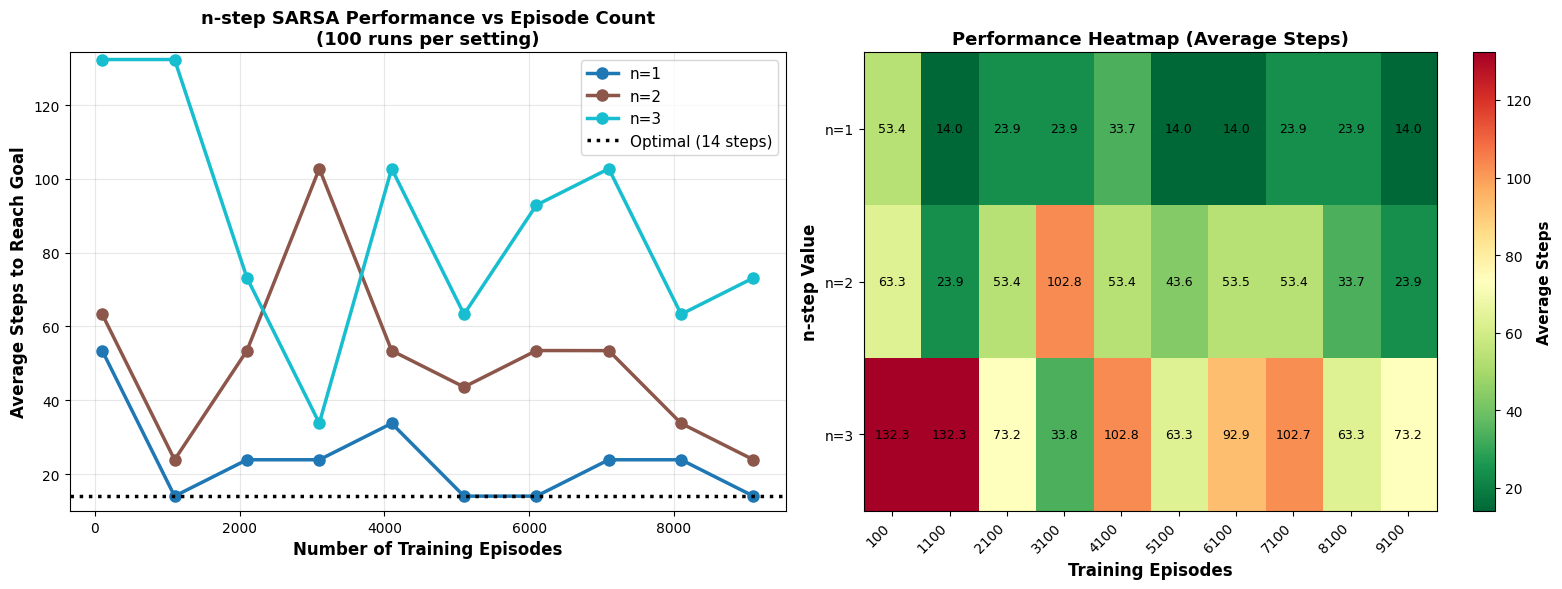


DETAILED SUMMARY: n-step SARSA Performance

n = 1:
  Episodes → Average Steps
      100:  53.44 
     1100:  14.00 ✓ OPTIMAL
     2100:  23.86 
     3100:  23.86 
     4100:  33.72 
     5100:  14.00 ✓ OPTIMAL
     6100:  14.00 ✓ OPTIMAL
     7100:  23.86 
     8100:  23.86 
     9100:  14.00 ✓ OPTIMAL

n = 2:
  Episodes → Average Steps
      100:  63.30 
     1100:  23.86 
     2100:  53.44 
     3100: 102.76 
     4100:  53.44 
     5100:  43.58 
     6100:  53.46 
     7100:  53.44 
     8100:  33.72 
     9100:  23.86 

n = 3:
  Episodes → Average Steps
      100: 132.34 
     1100: 132.34 
     2100:  73.18 
     3100:  33.78 
     4100: 102.76 
     5100:  63.30 
     6100:  92.88 
     7100: 102.74 
     8100:  63.30 
     9100:  73.16 

BEST n VALUE FOR EACH EPISODE COUNT
Episodes   100: n= 1 with 53.44 avg steps
Episodes  1100: n= 1 with 14.00 avg steps
Episodes  2100: n= 1 with 23.86 avg steps
Episodes  3100: n= 1 with 23.86 avg steps
Episodes  4100: n= 1 with 33.72 avg step

In [ ]:

# Test n-step SARSA with different n values
print("\n" + "="*80)
print("COMPREHENSIVE N-STEP SARSA ANALYSIS")
print("="*80 + "\n")
REWARDS = {" ": -1, "#": -1, "+": 10, "-": -10}
# Setup parameters
n_values = [1,2,3]
episode_counts = list(range(100, 10100, 1000))  # [100, 1100, 2100, ..., 10100]
num_experiments = 100
alpha = 0.5
gamma = 0.9
epsilon = 0.1

# Create world
world_nstep = World(8, 8)
world_nstep.add_terminal(7, 7, "+")
start_state = (0, 0)
optimal_steps = 14

def measure_performance(Q, world, start_state, max_steps=1000):
    s = start_state
    steps = 0

    while not world.is_terminal(*s) and steps < max_steps:
        a = np.argmax(Q[*s, :])
        s = world.get_next_state(s, ACTIONS[a])
        steps += 1

    return steps

def run_nstep_analysis(world, start_state, n_values, episode_counts, num_experiments, alpha, gamma, epsilon):
    """
    Comprehensive n-step SARSA analysis with multiple runs and episode counts.
    Returns dictionary mapping n values to lists of average steps.
    """
    results = {n: [] for n in n_values}
    
    print(f"Configuration:")
    print(f"  - n values: {n_values}")
    print(f"  - Episode counts: {episode_counts}")
    print(f"  - Experiments per setting: {num_experiments}")
    print(f"  - Alpha: {alpha}, Gamma: {gamma}, Epsilon: {epsilon}\n")
    
    for episodes in episode_counts:
        print(f"Training with {episodes:,} episodes:")
        
        for n in n_values:
            steps_list = []
            
            for exp in range(num_experiments):
                # Train n-step SARSA
                q_table, _ = n_step_sarsa(world, start_state, n=n, alpha=alpha, 
                                         gamma=gamma, epsilon=epsilon, episodes=episodes)
                # Measure performance (steps to goal with greedy policy)
                steps = measure_performance(q_table, world, start_state)
        
                steps_list.append(steps)
            
            avg_steps = np.mean(steps_list)
            std_steps = np.std(steps_list)
            results[n].append(avg_steps)
            
            print(f"  n={n:2d}: {avg_steps:6.2f} steps (±{std_steps:5.2f})")
        
        print()
    
    return results

# Run the comprehensive analysis
nstep_results = run_nstep_analysis(
    world_nstep, 
    start_state, 
    n_values, 
    episode_counts, 
    num_experiments, 
    alpha, 
    gamma, 
    epsilon
)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Performance across episodes for each n
colors_nstep = plt.cm.tab10(np.linspace(0, 1, len(n_values)))

for idx, n in enumerate(n_values):
    ax1.plot(episode_counts, nstep_results[n], marker='o', linewidth=2.5, 
             label=f'n={n}', color=colors_nstep[idx], markersize=8)

ax1.axhline(y=optimal_steps, color='black', linestyle=':', linewidth=2.5, 
            label=f'Optimal ({optimal_steps} steps)')
ax1.set_xlabel('Number of Training Episodes', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Steps to Reach Goal', fontsize=12, fontweight='bold')
ax1.set_title('n-step SARSA Performance vs Episode Count\n(100 runs per setting)', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([10, max(max(nstep_results[n]) for n in n_values) + 2])

# Plot 2: Performance heatmap
heatmap_data = np.array([nstep_results[n] for n in n_values])
im = ax2.imshow(heatmap_data, cmap='RdYlGn_r', aspect='auto', vmin=optimal_steps, 
                vmax=heatmap_data.max())

ax2.set_xticks(range(len(episode_counts)))
ax2.set_xticklabels([f'{ep}' for ep in episode_counts], rotation=45, ha='right')
ax2.set_yticks(range(len(n_values)))
ax2.set_yticklabels([f'n={n}' for n in n_values])
ax2.set_xlabel('Training Episodes', fontsize=12, fontweight='bold')
ax2.set_ylabel('n-step Value', fontsize=12, fontweight='bold')
ax2.set_title('Performance Heatmap (Average Steps)', fontsize=13, fontweight='bold')

# Add text annotations
for i in range(len(n_values)):
    for j in range(len(episode_counts)):
        text = ax2.text(j, i, f'{heatmap_data[i, j]:.1f}',
                       ha="center", va="center", color="black", fontsize=9)

cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Average Steps', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed summary
print("\n" + "="*80)
print("DETAILED SUMMARY: n-step SARSA Performance")
print("="*80)

for n in n_values:
    print(f"\nn = {n}:")
    print(f"  Episodes → Average Steps")
    for episodes, avg_steps in zip(episode_counts, nstep_results[n]):
        status = "✓ OPTIMAL" if avg_steps <= optimal_steps else ""
        print(f"    {episodes:>5}: {avg_steps:6.2f} {status}")

# Identify best n for each episode count
print("\n" + "="*80)
print("BEST n VALUE FOR EACH EPISODE COUNT")
print("="*80)

for j, episodes in enumerate(episode_counts):
    best_n = min(n_values, key=lambda n: nstep_results[n][j])
    best_steps = nstep_results[best_n][j]
    print(f"Episodes {episodes:>5}: n={best_n:2d} with {best_steps:.2f} avg steps")

# Overall best n
all_steps = []
for n in n_values:
    all_steps.extend(nstep_results[n])

best_overall_n = min(n_values, key=lambda n: np.mean(nstep_results[n]))
best_overall_steps = np.mean(nstep_results[best_overall_n])

print(f"\nOverall best n: {best_overall_n} (avg {best_overall_steps:.2f} steps)")

# Time to reach optimal for each n
print("\n" + "="*80)
print("EPISODES NEEDED TO REACH OPTIMAL PERFORMANCE")
print("="*80)

for n in n_values:
    for episodes, avg_steps in zip(episode_counts, nstep_results[n]):
        if avg_steps <= optimal_steps + 0.5:
            print(f"n={n:2d}: {episodes:>5} episodes")
            break
    else:
        print(f"n={n:2d}: Did not reach optimal within {episode_counts[-1]} episodes")




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import trapezoid

def greedy_rollout(Q, world, start_state, max_steps=200):
    s = start_state
    steps = 0

    while not world.is_terminal(*s) and steps < max_steps:
        a = np.argmax(Q[*s, :])
        s = world.get_next_state(s, ACTIONS[a])
        steps += 1

    return steps

def nstep_sarsa_learning_curve(
        world,
        start_state,
        n_values=(1,2,3,4,5),
        total_episodes=5000,
        eval_interval=50,
        runs=40,
        alpha=0.5,
        gamma=0.9,
        epsilon=0.1,
        optimal_steps=None
    ):
    """
    Proper evaluation of n-step SARSA.

    Measures *learning speed* instead of final performance by
    periodically evaluating a greedy policy during training.

    Returns:
        dict: learning curves for each n
    """

    eval_points = total_episodes // eval_interval
    curves = {}

    print("="*70)
    print("Running true n-step SARSA learning-curve experiment")
    print("="*70)
    print(f"Total episodes: {total_episodes}")
    print(f"Evaluation interval: {eval_interval}")
    print(f"Runs per setting: {runs}")
    print()

    for n in n_values:

        print(f"Testing n = {n}")
        curve = np.zeros(eval_points)

        for run in range(runs):

            # Fresh Q for each independent run
            Q = np.full((world.width, world.height, len(ACTIONS)), 0.0)

            episode_counter = 0
            eval_index = 0

            while episode_counter < total_episodes:

                Q, _ = n_step_sarsa(world, start_state, n=n,
                    Q_table=Q,
                    alpha=alpha,
                    gamma=gamma,
                    epsilon=epsilon,
                    episodes=eval_interval)

                episode_counter += eval_interval

                steps = greedy_rollout(Q, world, start_state)

                curve[eval_index] += steps
                eval_index += 1

        # average across runs
        curve /= runs
        curves[n] = curve

    plt.figure(figsize=(11,6))

    for n in n_values:
        x = np.arange(len(curves[n])) * eval_interval
        plt.plot(x, curves[n], linewidth=2.5, label=f"n = {n}")

    if optimal_steps is not None:
        plt.axhline(optimal_steps, linestyle="--", color="black",
                    linewidth=2, label="Optimal path")

    plt.xlabel("Training Episodes")
    plt.ylabel("Steps to Goal (Greedy Policy)")
    plt.title("Learning Curves — n-step SARSA")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.ylim(10, 60)
    plt.show()

    print("\nArea Under Curve (lower is better):")

    for n in n_values:
        auc = trapezoid(curves[n], dx=eval_interval)
        print(f"n = {n}: AUC = {auc:.2f}")

    best_n = min(n_values, key=lambda n: trapezoid(curves[n], dx=eval_interval))
    print(f"\nBest overall n (fastest learner): n = {best_n}")

    return curves


Running true n-step SARSA learning-curve experiment
Total episodes: 5000
Evaluation interval: 50
Runs per setting: 40

Testing n = 1
Testing n = 2
Testing n = 3


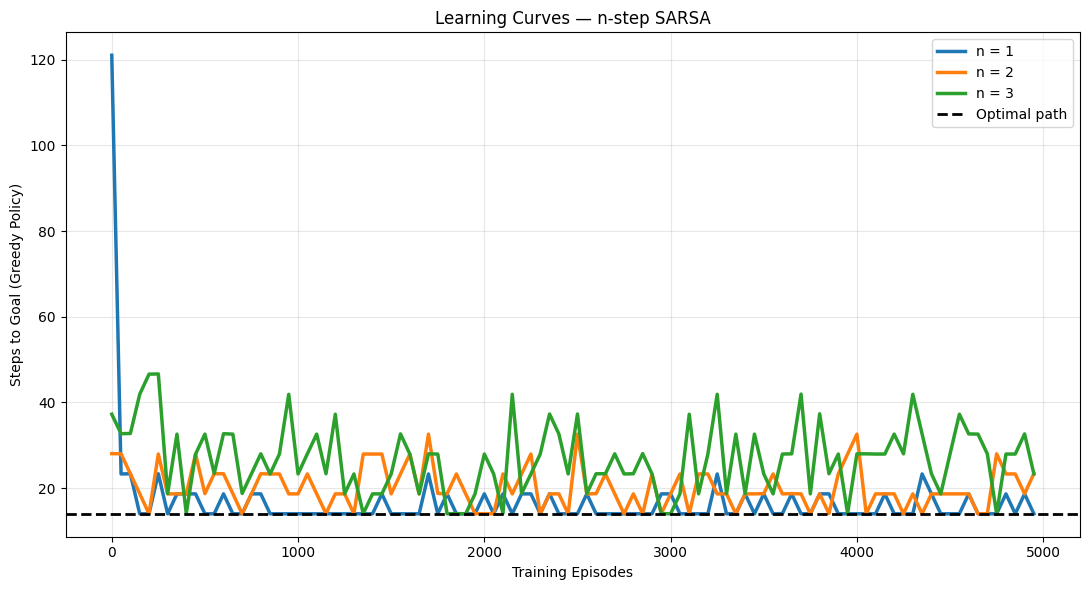


Area Under Curve (lower is better):
n = 1: AUC = 80821.25
n = 2: AUC = 99226.25
n = 3: AUC = 132563.75

Best overall n (fastest learner): n = 1


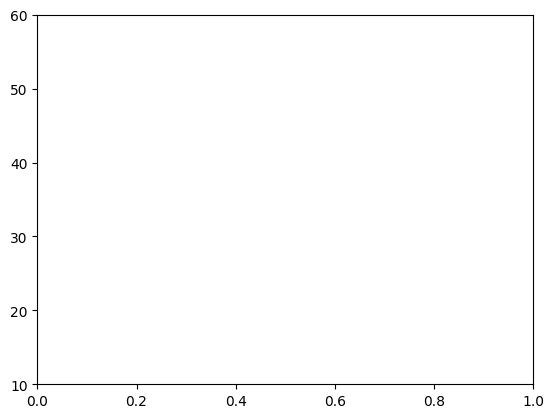

In [36]:
curves = nstep_sarsa_learning_curve(
    world_nstep,
    start_state=(0,0),
    n_values=[1,2,3],
    total_episodes=5000,
    eval_interval=50,
    runs=40,
    alpha=0.5,
    gamma=0.9,
    epsilon=0.1,
    optimal_steps=14
)